In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/weather_Madrid.csv')
df.head()

,date,temperature_2m,relative_humidity_2m,wind_speed_10m,rain
0,2025-07-26 00:00:00+00:00,20.859001,41.0,12.738099,0.0
1,2025-07-26 01:00:00+00:00,19.509000,45.0,11.246759,0.0
2,2025-07-26 02:00:00+00:00,18.459000,48.0,11.592894,0.0
3,2025-07-26 03:00:00+00:00,17.409000,54.0,11.090103,0.0
4,2025-07-26 04:00:00+00:00,16.709000,56.0,10.464797,0.0


In [2]:
df['date'] = pd.to_datetime(df['date'])

# Find the last date (without time)
last_day = df['date'].dt.date.max()

# Filter out rows from the last day
df = df[df['date'].dt.date != last_day]
df.tail()

,date,temperature_2m,relative_humidity_2m,wind_speed_10m,rain
1435,2025-09-23 19:00:00+00:00,18.209000,30.0,11.720751,0.0
1436,2025-09-23 20:00:00+00:00,16.909000,32.0,12.758432,0.0
1437,2025-09-23 21:00:00+00:00,15.759001,34.0,11.966953,0.0
1438,2025-09-23 22:00:00+00:00,14.809000,37.0,10.464797,0.0
1439,2025-09-23 23:00:00+00:00,13.809000,42.0,12.481153,0.0


In [3]:
train = df.iloc[:-24*7]
test = df.iloc[-24*7:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1272, 5)
Test shape: (168, 5)


### Forecaster

In [27]:
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.transformations.series.detrend import Detrender
from sktime.forecasting.compose import TransformedTargetForecaster
from sktime.transformations.series.detrend import Deseasonalizer
from sktime.forecasting.arima import ARIMA

def forecast(train, test):
  sp = 168  # 24 hours * 7 days
  
  forecaster = TransformedTargetForecaster(
    [
        ("deseasonalize", Deseasonalizer(model="additive", sp=sp)),
        ("detrend", Detrender(forecaster=PolynomialTrendForecaster(degree=1))),
        ("forecast", ARIMA()),
    ]
  )

  fh = np.arange(1, len(test)+1)

  forecaster.fit(train)
  pred = forecaster.predict(fh)

  return pred.round()

In [28]:
pred_temperature_2m = forecast(train['temperature_2m'], test['date'])

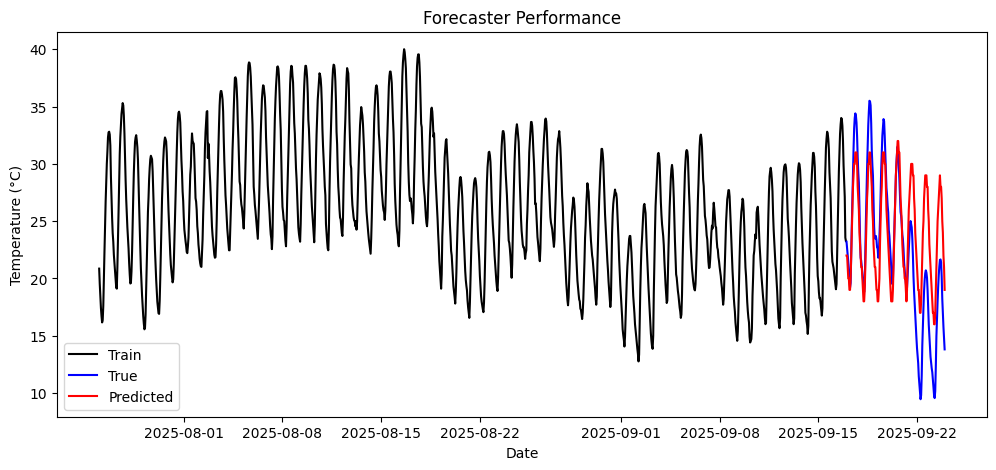

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train.date, train['temperature_2m'], label="Train", color="black")
plt.plot(test.date, test['temperature_2m'], label="True", color="blue")
plt.plot(test.date, pred_temperature_2m, label="Predicted", color="red")
plt.title("Forecaster Performance")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [30]:
from sktime.performance_metrics.forecasting import MeanSquaredError
from sktime.performance_metrics.forecasting import MeanAbsoluteError
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError

mse = MeanSquaredError()
mape = MeanAbsolutePercentageError()
mae = MeanAbsoluteError()

print('MSE:', round(mse(y_true=test['temperature_2m'], y_pred=pred_temperature_2m),4))
print('MAPE:', round(mape(y_true=test['temperature_2m'], y_pred=pred_temperature_2m),4))
print('MAE:', round(mae(y_true=test['temperature_2m'], y_pred=pred_temperature_2m),4))

MSE: 22.051
MAPE: 0.2142
MAE: 3.8107


c:\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Ablation study

In [32]:
def forecast_without_deseasonalizer(train, test):
  sp = 168  # 24 hours * 7 days
  
  forecaster = TransformedTargetForecaster(
    [
        #("deseasonalize", Deseasonalizer(model="additive", sp=sp)),
        ("detrend", Detrender(forecaster=PolynomialTrendForecaster(degree=1))),
        ("forecast", ARIMA()),
    ]
  )

  fh = np.arange(1, len(test)+1)

  forecaster.fit(train)
  pred = forecaster.predict(fh)

  return pred.round()

preds = forecast_without_deseasonalizer(train['temperature_2m'], test['date'])

print('MSE:', round(mse(y_true=test['temperature_2m'], y_pred=preds),4))
print('MAPE:', round(mape(y_true=test['temperature_2m'], y_pred=preds),4))
print('MAE:', round(mae(y_true=test['temperature_2m'], y_pred=preds),4))

MSE: 41.1287
MAPE: 0.2692
MAE: 5.1465


c:\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [35]:
def forecast_without_detrender(train, test):
  sp = 168  # 24 hours * 7 days
  
  forecaster = TransformedTargetForecaster(
    [
        ("deseasonalize", Deseasonalizer(model="additive", sp=sp)),
        #("detrend", Detrender(forecaster=PolynomialTrendForecaster(degree=1))),
        ("forecast", ARIMA()),
    ]
  )

  fh = np.arange(1, len(test)+1)

  forecaster.fit(train)
  pred = forecaster.predict(fh)

  return pred.round()

preds = forecast_without_detrender(train['temperature_2m'], test['date'])

print('MSE:', round(mse(y_true=test['temperature_2m'], y_pred=preds),4))
print('MAPE:', round(mape(y_true=test['temperature_2m'], y_pred=preds),4))
print('MAE:', round(mae(y_true=test['temperature_2m'], y_pred=preds),4))

MSE: 40.6243
MAPE: 0.282
MAE: 4.7669


c:\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
